In [1]:
import os

os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")

from pathlib import Path

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(PROJECT_DIR)

# DTensor workaround — same as infer.py / pretrain.py (transformers 4.52.4 + single-GPU).
try:
    from torch.distributed.tensor import DTensor
except ImportError:

    class DTensor:
        pass


import transformers.modeling_utils

transformers.modeling_utils.DTensor = DTensor

from util.env import load_dotenv

load_dotenv()

from paths import HF_CACHE_DIR

os.environ.setdefault("HF_HOME", HF_CACHE_DIR)

import json
import numpy as np
import torch
import matplotlib.pyplot as plt

from omegaconf import open_dict
from hydra import initialize_config_dir, compose
from hydra.core.global_hydra import GlobalHydra
from transformers import AutoTokenizer, StoppingCriteria, StoppingCriteriaList

from model.util import load_model_from_config, load_checkpoint
from model.sharing_strategy import SHARING_STRATEGY
from util.config import preprocess_config
from lm_dataset.multimodal_vocab_shared_caption_scene_desc import MODALITIES, PAD_ID
from visualization.decode import _resolve_cosmos_decoder_jit

print("Modalities in vocab:", list(MODALITIES.keys()))
print("PAD_ID:", PAD_ID)

/home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Modalities in vocab: ['tok_rgb@256', 'tok_depth@256', 'tok_normal@256', 'caption', 'scene_desc']
PAD_ID: 242270


In [3]:
# initialize_config_dir wants an absolute path. Hydra forbids re-initialising
# in the same process, so clear any previous instance (e.g. from re-running the cell).
if GlobalHydra().is_initialized():
    GlobalHydra().clear()
with initialize_config_dir(config_dir=str(PROJECT_DIR / "conf"), version_base=None):
    cfg = compose(config_name="infer/mor_5000_multimodality_3r.yaml")

with open_dict(cfg):
    cfg.wandb = False
    cfg.wandb_entity = ""
    cfg.wandb_project = "inference"
    cfg.wandb_run_name = "inference"
    cfg.resume_from_checkpoint = False
cfg = preprocess_config(cfg)

DEVICE = cfg.infer.device if torch.cuda.is_available() else "cpu"
print(f"Building model on {DEVICE}…")

model = load_model_from_config(cfg)
if cfg.recursive.get("enable"):
    model, _ = SHARING_STRATEGY[cfg.model](cfg, model)
if "kv_sharing" in cfg and cfg.kv_sharing.get("enable"):
    model.set_kv_sharing_config(cfg)
if "mor" in cfg and cfg.mor.get("enable"):
    if cfg.mor.type == "expert":
        model.transform_layer_to_mor_expert(cfg)
    elif cfg.mor.type == "token":
        model.transform_layer_to_mor_token(cfg)

print(f"Loading checkpoint: {cfg.infer.checkpoint}")
model = load_checkpoint(model, cfg.infer.checkpoint)
model.to(DEVICE).eval()

print(
    "Ready. layers =",
    model.config.num_hidden_layers,
    " vocab =",
    model.config.vocab_size,
    " max_pos =",
    model.config.max_position_embeddings,
)

-------------------------------Preprocess Config -------------------------------
Automatically determining batch size based on `total_batch_size`
total_batch_size              : 256 (given)
torch.cuda.device_count()     : 1
per_device_train_batch_size   : 8 (given)
gradient_accumulation_steps   : 32 (computed)
actual total batch size       : 256
Setting output_dir  : mor_5000_multimodality_3r_infer
Using deepspeed config = /home/hugues/Documents/Visual_Intelligence/Mixture-of-Recursions-for-Vision/ds_configs/stage2.config
--------------------------------------------------------------------------------
Building model on cuda…
Initializing model from scratch...
Using custom config for vanilla model...
 num_hidden_layers: 29
 vocab_size: 242271
Loading checkpoint: gbasi18/MoR-5000-Multimodality-all-modalities


Fetching 6 files: 100%|██████████| 6/6 [00:00<00:00, 18369.21it/s]


  Cached at: /home/hugues/.cache/huggingface/hub/models--gbasi18--MoR-5000-Multimodality-all-modalities/snapshots/837cbe67df057b50040122bf721d1b03cc66bfaa
Ready. layers = 29  vocab = 242271  max_pos = 1048


In [4]:
PATCH_GRID = cfg.infer.patch_grid_size  # 16 -> 16x16=256 image tokens
COSMOS_PATH = cfg.infer.cosmos_model_path
TEXT_MAX_LEN = cfg.multimodal.get("text_max_length", 64)
GPT2_TOK = AutoTokenizer.from_pretrained("gpt2")

# ------------------------- Cosmos decoder cache -------------------------
_cosmos_decoder = None


def _get_cosmos_decoder():
    """ImageTokenizer is expensive to build; cache one instance for the whole notebook."""
    global _cosmos_decoder
    if _cosmos_decoder is None:
        from cosmos_tokenizer.image_lib import ImageTokenizer

        decoder_jit = _resolve_cosmos_decoder_jit(COSMOS_PATH)
        _cosmos_decoder = ImageTokenizer(
            checkpoint_dec=decoder_jit, device="cuda", dtype="bfloat16"
        )
    return _cosmos_decoder


def decode_image_tokens(raw_tokens: np.ndarray) -> np.ndarray | None:
    """raw_tokens: (256,) int VQ indices in [0, 64000) -> HxWx3 uint8 image, or None."""
    if raw_tokens.size != PATCH_GRID * PATCH_GRID:
        print(f"  [warn] need {PATCH_GRID**2} tokens, got {raw_tokens.size}")
        return None
    if not (DEVICE == "cuda" and torch.cuda.is_available()):
        print("  [warn] Cosmos decode requires CUDA.")
        return None
    tokenizer = _get_cosmos_decoder()
    indices = (
        torch.from_numpy(raw_tokens.astype(np.int64)).reshape(1, PATCH_GRID, PATCH_GRID).to("cuda")
    )
    with torch.no_grad():
        decoded = tokenizer.decode(indices).float().cpu().numpy()[0]  # (3, H, W) in ~[-1, 1]
    decoded = np.clip((decoded + 1.0) / 2.0, 0.0, 1.0)
    return (decoded.transpose(1, 2, 0) * 255.0 + 0.5).astype(np.uint8)


# ------------------------- Chunk builders -------------------------
def chunk_text(modality: str, text: str, *, close: bool = True) -> torch.Tensor:
    """<BO_mod> + GPT-2(text) + <EO_mod> (or no EO if close=False)."""
    info = MODALITIES[modality]
    assert info.data_type == "text", f"{modality} is not a text modality"
    ids = GPT2_TOK(text, truncation=True, max_length=TEXT_MAX_LEN, return_tensors="pt")[
        "input_ids"
    ][0].long()
    parts = [torch.tensor([info.bo_id]), ids + info.codebook_offset]
    if close:
        parts.append(torch.tensor([info.eo_id]))
    return torch.cat(parts)


def chunk_tokens(
    modality: str, source, *, aug_idx: int = 0, prefix_len: int | None = None, close: bool = True
) -> torch.Tensor:
    """source can be a path to a (K,N) .npy or a 1D array of raw codebook indices."""
    info = MODALITIES[modality]
    assert info.data_type == "tokens", f"{modality} is not a tokens modality"
    arr = np.load(source) if isinstance(source, (str, Path)) else np.asarray(source)
    if arr.ndim == 2:
        arr = arr[aug_idx]
    body = torch.from_numpy(arr.flatten()).long() + info.codebook_offset
    if prefix_len is not None:
        body = body[:prefix_len]
        close = False  # prefix mode: no EO; the model continues the same modality
    parts = [torch.tensor([info.bo_id]), body]
    if close:
        parts.append(torch.tensor([info.eo_id]))
    return torch.cat(parts)


# ------------------------- Generation -------------------------
class _EoModStopping(StoppingCriteria):
    def __init__(self, eo_id):
        self.eo_id = eo_id

    def __call__(self, input_ids, scores, **kwargs):
        return bool((input_ids[:, -1] == self.eo_id).all())


def generate(
    chunks: list[torch.Tensor],
    target_modality: str | None = None,
    *,
    continue_modality: str | None = None,
    max_new_tokens: int | None = None,
    do_sample: bool = False,
    temperature: float = 1.0,
    top_k: int = 0,
    top_p: float = 1.0,
    seed: int | None = None,
    use_cache: bool | None = None,
) -> torch.Tensor:
    """Generate body tokens conditioned on `chunks`.

    Two modes:
      - target_modality='X' (default): the prompt is `chunks + <BO_X>` and we stop at <EO_X>.
      - continue_modality='X': the last chunk must have been built with close=False, so the
        prompt already ends inside an open X-chunk; we just stop at <EO_X>.
        Used for prefix-completion (e.g. fill in the bottom half of an image).
    """
    if (target_modality is None) == (continue_modality is None):
        raise ValueError("pass exactly one of target_modality / continue_modality")

    if target_modality is not None:
        info = MODALITIES[target_modality]
        prompt = torch.cat([*chunks, torch.tensor([info.bo_id])]).unsqueeze(0)
    else:
        info = MODALITIES[continue_modality]
        prompt = torch.cat(chunks).unsqueeze(0)

    if max_new_tokens is None:
        max_new_tokens = 257 if info.data_type == "tokens" else (TEXT_MAX_LEN + 1)
    if use_cache is None:
        use_cache = bool(cfg.infer.use_cache)
    if seed is not None:
        torch.manual_seed(seed)

    do_sample_eff = do_sample or temperature != 1.0 or top_k != 0 or top_p != 1.0
    prompt = prompt.to(DEVICE)
    with torch.no_grad():
        out = model.generate(
            input_ids=prompt,
            attention_mask=torch.ones_like(prompt),
            max_new_tokens=max_new_tokens,
            use_cache=use_cache,
            stopping_criteria=StoppingCriteriaList([_EoModStopping(info.eo_id)]),
            do_sample=do_sample_eff,
            temperature=temperature if do_sample_eff else 1.0,
            top_k=top_k if do_sample_eff else 0,
            top_p=top_p if do_sample_eff else 1.0,
            pad_token_id=PAD_ID,
        )
    return out[0, prompt.shape[1] :].cpu()


# ------------------------- Display -------------------------
def _strip_specials(tokens: torch.Tensor, info) -> np.ndarray:
    body = tokens[(tokens != info.bo_id) & (tokens != info.eo_id) & (tokens != PAD_ID)]
    return (body - info.codebook_offset).cpu().numpy()


def show_text(tokens: torch.Tensor, modality: str) -> str:
    raw = _strip_specials(tokens, MODALITIES[modality]).tolist()
    text = GPT2_TOK.decode(raw, skip_special_tokens=True)
    print(f"[{modality}] {text}")
    return text


def show_image(
    tokens_or_array,
    modality: str,
    *,
    ax=None,
    title: str | None = None,
    extra_prefix: np.ndarray | None = None,
):
    """Decode either a 1D array of raw VQ indices or a Tensor of generated unified-vocab tokens."""
    if isinstance(tokens_or_array, torch.Tensor):
        raw = _strip_specials(tokens_or_array, MODALITIES[modality])
    else:
        raw = np.asarray(tokens_or_array).flatten()
    if extra_prefix is not None:
        raw = np.concatenate([np.asarray(extra_prefix).flatten(), raw])
    img = decode_image_tokens(raw[: PATCH_GRID * PATCH_GRID])
    if img is None:
        return None
    if ax is None:
        _, ax = plt.subplots(figsize=(3, 3))
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title or modality, fontsize=9)
    return img


def show(tokens: torch.Tensor, modality: str, **kwargs):
    """Auto-dispatch: text -> show_text, image tokens -> show_image."""
    if MODALITIES[modality].data_type == "tokens":
        return show_image(tokens, modality, **kwargs)
    return show_text(tokens, modality)


print("helpers ready.")

helpers ready.


In [5]:
SAMPLE_ID = "00007"  # change to any 5-digit id under data/clevr_dataset/test/
AUG_IDX = 0  # which of the K augmentations to use as ground truth
DATA_TEST = Path("data/clevr_dataset/test")

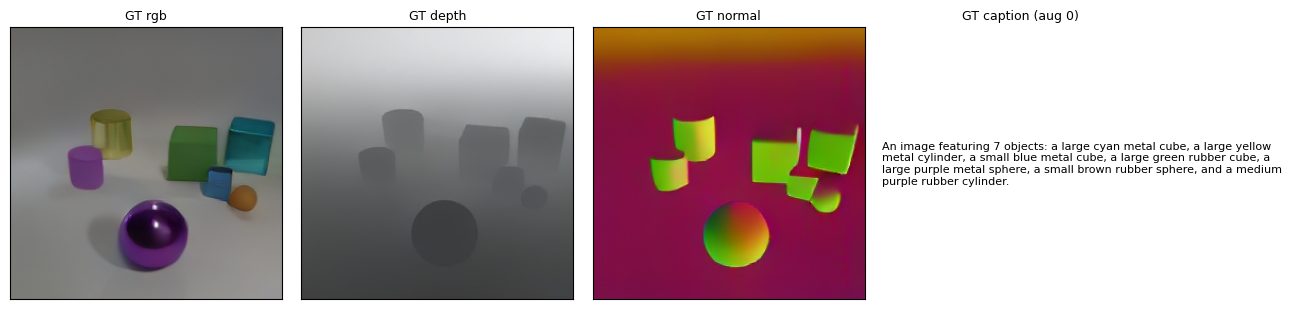

In [6]:
ref_rgb = np.load(DATA_TEST / "tok_rgb@256" / f"{SAMPLE_ID}.npy")[AUG_IDX]
ref_depth = np.load(DATA_TEST / "tok_depth@256" / f"{SAMPLE_ID}.npy")[AUG_IDX]
ref_normal = np.load(DATA_TEST / "tok_normal@256" / f"{SAMPLE_ID}.npy")[AUG_IDX]
with open(DATA_TEST / "caption" / f"{SAMPLE_ID}.json") as f:
    ref_captions = json.load(f)

fig, axes = plt.subplots(1, 4, figsize=(13, 3.2))
show_image(ref_rgb, "tok_rgb@256", ax=axes[0], title="GT rgb")
show_image(ref_depth, "tok_depth@256", ax=axes[1], title="GT depth")
show_image(ref_normal, "tok_normal@256", ax=axes[2], title="GT normal")
axes[3].axis("off")
axes[3].set_title("GT caption (aug 0)", fontsize=9)
axes[3].text(0.0, 0.5, ref_captions[AUG_IDX], wrap=True, fontsize=8, va="center")
plt.tight_layout()
plt.show()

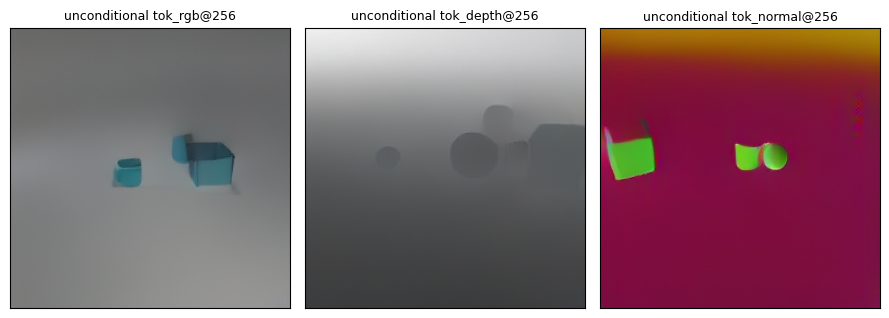


Unconditional captions:
[caption] In this image, you can see a small red cylinder and a large gray cube.
[caption] In this composition with seven objects, you can see a small yellow metal cube, a small gray rubber sphere, a large green metal sphere, a medium yellow rubber sphere, a medium red rubber cylinder, a small yellow metal cube, and a medium brown metal sphere.
[caption] This composition includes three items: a large blue cylindrical metal piece, a medium-sized red rubber tube, and a medium-sized brown cube crafted from metal.


In [7]:
image_targets = ["tok_rgb@256", "tok_depth@256", "tok_normal@256"]

fig, axes = plt.subplots(1, len(image_targets), figsize=(3 * len(image_targets), 3.2))
for ax, target in zip(axes, image_targets):
    out = generate([], target_modality=target, do_sample=True, temperature=0.9, seed=0)
    show_image(out, target, ax=ax, title=f"unconditional {target}")
plt.tight_layout()
plt.show()

print("\nUnconditional captions:")
for seed in [0, 1, 2]:
    out = generate([], target_modality="caption", do_sample=True, temperature=0.9, seed=seed)
    show_text(out, "caption")

MoR layer hooked. num_recursion = 3  use_cache = False


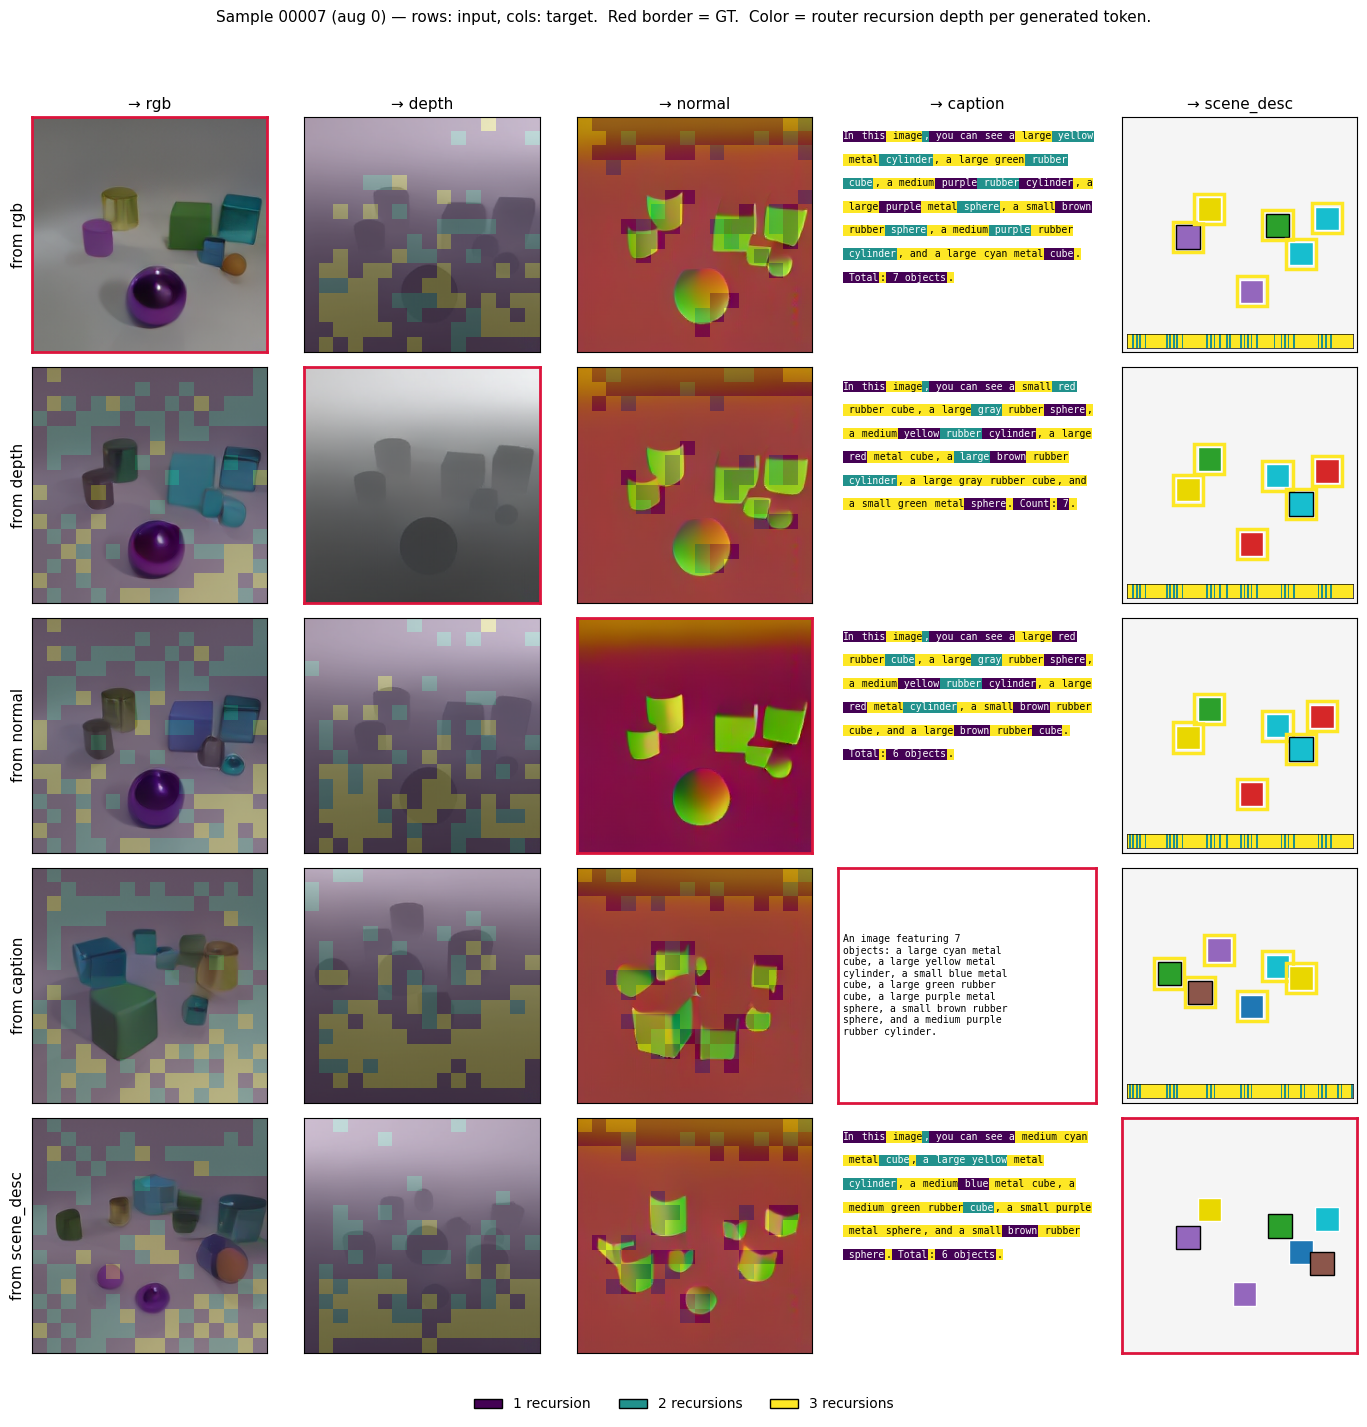

In [8]:
import re
import textwrap
import numpy.ma as ma
import matplotlib as mpl
from matplotlib.patches import Rectangle, Patch
from matplotlib.colors import ListedColormap, BoundaryNorm, to_hex, to_rgba

OVERLAY_ALPHA = 0.22
CAPTION_FONTSIZE = 7
CAPTION_FONTFAMILY = "monospace"
CAPTION_LINE_H = 0.10
CAPTION_TOKEN_GAP = 0.004  # axes-fraction gap between adjacent tokens
CAPTION_BBOX_PAD = 0.5     # bbox padding in points


# ---------- scene_desc parser ----------
CLEVR_COLOR_MAP = {
    "gray": "#7f7f7f", "red": "#d62728", "blue": "#1f77b4",
    "green": "#2ca02c", "brown": "#8c564b", "purple": "#9467bd",
    "cyan": "#17becf", "yellow": "#e9d700",
}

_SCENE_OBJ_RE = re.compile(
    r"Object\s+\d+\s*-\s*Position:\s*x=(\d+)\s*y=(\d+)\s*"
    r"Shape:\s*(\w+)\s*Color:\s*(\w+)\s*Material:\s*(\w+)",
    re.IGNORECASE,
)


def _scene_desc_to_text(payload):
    if isinstance(payload, torch.Tensor):
        raw = _strip_specials(payload, MODALITIES["scene_desc"]).tolist()
        return GPT2_TOK.decode(raw, skip_special_tokens=True)
    return payload


# ---------- input chunk builder + GT payload ----------
with open(DATA_TEST / "scene_desc" / f"{SAMPLE_ID}.json") as f:
    ref_scene_descs = json.load(f)

GT_PAYLOAD = {
    "tok_rgb@256": ref_rgb,
    "tok_depth@256": ref_depth,
    "tok_normal@256": ref_normal,
    "caption": ref_captions[AUG_IDX],
    "scene_desc": ref_scene_descs[AUG_IDX],
}

SHORT_NAME = {
    "tok_rgb@256": "rgb", "tok_depth@256": "depth", "tok_normal@256": "normal",
    "caption": "caption", "scene_desc": "scene_desc",
}


def build_input_chunk(modality: str) -> torch.Tensor:
    payload = GT_PAYLOAD[modality]
    if MODALITIES[modality].data_type == "tokens":
        return chunk_tokens(modality, payload)
    return chunk_text(modality, payload)


# ---------- MoR router decision capture ----------
def _find_mor_layer(m):
    for sub in m.modules():
        if type(sub).__name__ == "MoRLlamaDecoderLayer":
            return sub
    return None


MOR_LAYER = _find_mor_layer(model)
NUM_RECUR = int(cfg.recursive.num_recursion)
assert MOR_LAYER is not None, (
    "No MoRLlamaDecoderLayer found — this checkpoint isn't MoR-routed, "
    "so per-token recursion depth is undefined."
)
USE_CACHE = bool(cfg.infer.use_cache)
print(f"MoR layer hooked. num_recursion = {NUM_RECUR}  use_cache = {USE_CACHE}")

_PLASMA = mpl.colormaps["viridis"]
DEPTH_COLORS = [
    to_hex(_PLASMA(i / max(1, NUM_RECUR - 1))) for i in range(NUM_RECUR)
]
DEPTH_CMAP = ListedColormap(DEPTH_COLORS)
DEPTH_NORM = BoundaryNorm(
    boundaries=[i - 0.5 for i in range(NUM_RECUR + 1)], ncolors=NUM_RECUR
)


def _text_color_for(bg_hex: str) -> str:
    r, g, b, _ = to_rgba(bg_hex)
    return "white" if (0.299 * r + 0.587 * g + 0.114 * b) < 0.5 else "black"


class RoutingRecorder:
    def __init__(self, layer):
        self.layer = layer
        self.chunks = []
        self._handle = None

    def __enter__(self):
        self.chunks.clear()

        def _hook(_mod, _inp, out):
            idx = getattr(out, "token_expert_indices", None)
            if idx is not None:
                self.chunks.append(idx.detach().cpu()[0])

        self._handle = self.layer.register_forward_hook(_hook)
        return self

    def __exit__(self, *a):
        self._handle.remove()

    def all_depths(self):
        if not self.chunks:
            return torch.empty(0, dtype=torch.long)
        non_caching = len(self.chunks) >= 2 and self.chunks[1].numel() > 1
        if non_caching:
            return max(self.chunks, key=lambda c: c.numel())
        return torch.cat(self.chunks)


def generate_with_routing(chunks, target_modality, **kw):
    prompt_len = sum(c.numel() for c in chunks) + 1
    with RoutingRecorder(MOR_LAYER) as rec:
        out = generate(chunks, target_modality=target_modality, **kw)
    depths_all = rec.all_depths()
    n_gen = out.numel()
    take = max(0, min(n_gen, depths_all.numel() - prompt_len))
    depths = torch.full((n_gen,), -1, dtype=torch.long)
    if take > 0:
        depths[:take] = depths_all[prompt_len:prompt_len + take]
    return out, depths


def body_and_depths(out, depths, modality):
    info = MODALITIES[modality]
    mask = (out != info.bo_id) & (out != info.eo_id) & (out != PAD_ID)
    return out[mask], depths[mask]


def _per_token_pieces_and_depths(out, depths, modality):
    info = MODALITIES[modality]
    body_t, body_d = body_and_depths(out, depths, modality)
    raw_ids = (body_t - info.codebook_offset).tolist()
    pieces = [GPT2_TOK.decode([rid]) for rid in raw_ids]
    return pieces, body_d.tolist()


# ---------- Image renderer with overlaid heatmap ----------
def _depth_grid_image(body_d_tensor):
    arr = body_d_tensor.numpy().astype(np.int64).copy()
    n_need = PATCH_GRID * PATCH_GRID
    if arr.size < n_need:
        arr = np.concatenate([arr, np.full(n_need - arr.size, -1, dtype=arr.dtype)])
    return arr[:n_need].reshape(PATCH_GRID, PATCH_GRID)


def show_image_with_routing(payload, modality, ax, depths=None):
    if isinstance(payload, torch.Tensor):
        raw = _strip_specials(payload, MODALITIES[modality])
    else:
        raw = np.asarray(payload).flatten()
    img = decode_image_tokens(raw[:PATCH_GRID * PATCH_GRID])
    if img is None:
        return
    ax.imshow(img)
    ax.set_xticks([])
    ax.set_yticks([])
    if depths is not None and isinstance(payload, torch.Tensor):
        _, body_d = body_and_depths(payload, depths, modality)
        grid = _depth_grid_image(body_d)
        H, W = img.shape[:2]
        masked = ma.masked_where(grid < 0, grid)
        ax.imshow(
            masked, cmap=DEPTH_CMAP, norm=DEPTH_NORM,
            interpolation="nearest", alpha=OVERLAY_ALPHA,
            extent=(-0.5, W - 0.5, H - 0.5, -0.5),
        )


# ---------- Deferred caption layout (measured AFTER fig.canvas.draw) ----------
# We collect (ax, pieces, depths) and re-position them once the canvas knows
# the real text width — that's the only reliable way to avoid bbox overlap.
_PENDING_CAPTIONS: list = []


def show_caption_with_routing(payload, ax, depths=None):
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.set_facecolor("white")

    if depths is None or not isinstance(payload, torch.Tensor):
        show_caption_text(payload, ax)
        return

    pieces, dlist = _per_token_pieces_and_depths(payload, depths, "caption")
    if not pieces:
        return
    _PENDING_CAPTIONS.append((ax, pieces, dlist))


def _layout_pending_captions(fig):
    """Render colored-token captions with real-renderer measurement."""
    if not _PENDING_CAPTIONS:
        return
    fig.canvas.draw()  # ensure renderer exists
    renderer = fig.canvas.get_renderer()
    for ax, pieces, dlist in _PENDING_CAPTIONS:
        inv = ax.transAxes.inverted()
        x, y = 0.02, 0.94
        for piece, d in zip(pieces, dlist):
            if piece == "":
                continue
            bg = DEPTH_COLORS[d] if d >= 0 else "#dddddd"
            fg = _text_color_for(bg) if d >= 0 else "black"
            t = ax.text(
                x, y, piece, fontsize=CAPTION_FONTSIZE, va="top", ha="left",
                color=fg, family=CAPTION_FONTFAMILY,
                bbox=dict(facecolor=bg, edgecolor="none", pad=CAPTION_BBOX_PAD),
                transform=ax.transAxes,
            )
            bb_disp = t.get_window_extent(renderer=renderer)
            bb = bb_disp.transformed(inv)
            if bb.x1 > 0.99 and x > 0.02:
                t.remove()
                x = 0.02
                y -= CAPTION_LINE_H
                if y < 0.04:
                    break
                t = ax.text(
                    x, y, piece, fontsize=CAPTION_FONTSIZE, va="top", ha="left",
                    color=fg, family=CAPTION_FONTFAMILY,
                    bbox=dict(facecolor=bg, edgecolor="none", pad=CAPTION_BBOX_PAD),
                    transform=ax.transAxes,
                )
                bb = t.get_window_extent(renderer=renderer).transformed(inv)
            x = bb.x1 + CAPTION_TOKEN_GAP
    _PENDING_CAPTIONS.clear()


# ---------- scene_desc renderer ----------
def _objects_with_depths(payload, depths):
    pieces, dlist = _per_token_pieces_and_depths(payload, depths, "scene_desc")
    offsets = [0]
    for p in pieces:
        offsets.append(offsets[-1] + len(p))
    full_text = "".join(pieces)

    objs = []
    for m in _SCENE_OBJ_RE.finditer(full_text):
        s, e = m.span()
        tok_d = [
            dlist[i] for i in range(len(pieces))
            if dlist[i] >= 0 and not (offsets[i + 1] <= s or offsets[i] >= e)
        ]
        mean_d = int(round(sum(tok_d) / len(tok_d))) if tok_d else -1
        objs.append({
            "x": int(m.group(1)), "y": int(m.group(2)),
            "shape": m.group(3).lower(), "color": m.group(4).lower(),
            "material": m.group(5).lower(),
            "mean_depth": mean_d,
        })
    return objs, pieces, dlist


def show_scene_desc_with_routing(payload, ax, depths=None, *, box_size=10):
    ax.set_xlim(0, 100)
    ax.set_ylim(100, 0)
    ax.set_aspect("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_facecolor("#f5f5f5")

    if depths is not None and isinstance(payload, torch.Tensor):
        objs, pieces, dlist = _objects_with_depths(payload, depths)
    else:
        text = _scene_desc_to_text(payload)
        objs = [
            {"x": int(m.group(1)), "y": int(m.group(2)),
             "shape": m.group(3).lower(), "color": m.group(4).lower(),
             "material": m.group(5).lower(), "mean_depth": -1}
            for m in _SCENE_OBJ_RE.finditer(text)
        ]
        pieces, dlist = [], []

    for o in objs:
        face = CLEVR_COLOR_MAP.get(o["color"], "#000000")
        inner_edge = "white" if o["material"] == "metal" else "black"
        if o["mean_depth"] >= 0:
            outer = DEPTH_COLORS[o["mean_depth"]]
            ax.add_patch(Rectangle(
                (o["x"] - box_size / 2 - 1.4, o["y"] - box_size / 2 - 1.4),
                box_size + 2.8, box_size + 2.8,
                facecolor="none", edgecolor=outer, linewidth=2.5,
            ))
        ax.add_patch(Rectangle(
            (o["x"] - box_size / 2, o["y"] - box_size / 2),
            box_size, box_size,
            facecolor=face, edgecolor=inner_edge, linewidth=1.0,
        ))

    if dlist:
        inset = ax.inset_axes([0.02, 0.02, 0.96, 0.06])
        arr = np.array(dlist, dtype=np.int64).reshape(1, -1)
        masked = ma.masked_where(arr < 0, arr)
        inset.imshow(masked, cmap=DEPTH_CMAP, norm=DEPTH_NORM,
                     aspect="auto", interpolation="nearest")
        inset.set_xticks([])
        inset.set_yticks([])
        for s in inset.spines.values():
            s.set_edgecolor("black")
            s.set_linewidth(0.5)


def show_caption_text(payload, ax):
    if isinstance(payload, torch.Tensor):
        raw = _strip_specials(payload, MODALITIES["caption"]).tolist()
        text = GPT2_TOK.decode(raw, skip_special_tokens=True)
    else:
        text = payload
    ax.text(0.02, 0.5, textwrap.fill(text, width=28),
            fontsize=CAPTION_FONTSIZE, family=CAPTION_FONTFAMILY, va="center")


def render_cell_with_routing(payload, modality, ax, depths=None):
    if modality == "scene_desc":
        show_scene_desc_with_routing(payload, ax, depths=depths)
    elif modality == "caption":
        show_caption_with_routing(payload, ax, depths=depths)
    else:
        show_image_with_routing(payload, modality, ax, depths=depths)


# ---------- NxN grid ----------
MODS = list(MODALITIES.keys())
N = len(MODS)
_PENDING_CAPTIONS.clear()

fig, axes = plt.subplots(N, N, figsize=(2.8 * N, 2.8 * N))
for i, src in enumerate(MODS):
    for j, tgt in enumerate(MODS):
        ax = axes[i, j]
        if i == j:
            render_cell_with_routing(GT_PAYLOAD[tgt], tgt, ax)
            for sp in ax.spines.values():
                sp.set_edgecolor("crimson")
                sp.set_linewidth(2.0)
                sp.set_visible(True)
        else:
            chunks = [build_input_chunk(src)]
            out, depths = generate_with_routing(
                chunks, target_modality=tgt,
                do_sample=True, temperature=0.9, top_p=0.95, seed=0,
            )
            render_cell_with_routing(out, tgt, ax, depths=depths)
        if i == 0:
            ax.set_title(f"→ {SHORT_NAME[tgt]}", fontsize=11)
        if j == 0:
            ax.set_ylabel(f"from {SHORT_NAME[src]}", fontsize=11)

handles = [
    Patch(facecolor=DEPTH_COLORS[k], edgecolor="black",
          label=f"{k + 1} recursion{'s' if k > 0 else ''}")
    for k in range(NUM_RECUR)
]
fig.legend(handles=handles, loc="lower center", ncol=NUM_RECUR,
           bbox_to_anchor=(0.5, -0.01), frameon=False, fontsize=10)

fig.suptitle(
    f"Sample {SAMPLE_ID} (aug {AUG_IDX}) — rows: input, cols: target.  "
    "Red border = GT.  Color = router recursion depth per generated token.",
    fontsize=11, y=1.00,
)
plt.tight_layout(rect=[0, 0.03, 1, 0.97])
_layout_pending_captions(fig)  # measure-and-place captions now that fig is laid out
plt.show()


Per-depth token counts:
  depth 0 (1 recursion): 146 tokens
  depth 1 (2 recursions): 56 tokens
  depth 2 (3 recursions): 4 tokens
  depth 3 (4 recursions): 50 tokens
Saved GIF → outputs/recursion_steps_scene_desc__tok_rgb_at_256.gif


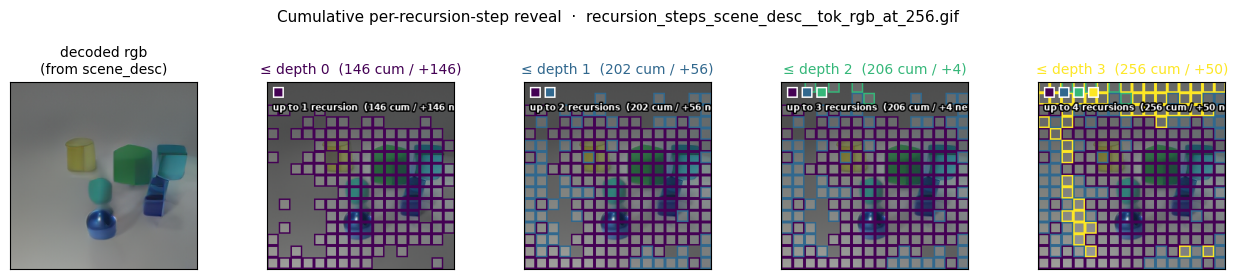

In [23]:
# ===== Per-recursion-step GIF (cumulative) =====
# Frame k highlights all patches with depth in 0..k (each in its own depth color).
# Patches from previous frames carry forward, so the GIF progressively reveals
# the full image as deeper recursion levels light up.
from PIL import Image as PILImage, ImageDraw, ImageFont

GIF_SRC = "scene_desc"
GIF_TGT = "tok_rgb@256"
GIF_DURATION_MS = 800
GIF_INACTIVE_SAT = 0.25   # 0 = full grayscale for not-yet-revealed patches
GIF_INACTIVE_DIM = 0.75
GIF_OUTLINE_WIDTH = 2
GIF_PATH = Path("outputs") / f"recursion_steps_{GIF_SRC}__{GIF_TGT.replace('@', '_at_')}.gif"
GIF_PATH.parent.mkdir(parents=True, exist_ok=True)

assert MODALITIES[GIF_TGT].data_type == "tokens", "GIF target must be an image modality."

chunks = [build_input_chunk(GIF_SRC)]
out_gif, depths_gif = generate_with_routing(
    chunks, target_modality=GIF_TGT,
    do_sample=True, temperature=0.9, top_p=0.95, seed=0,
)

raw_gif = _strip_specials(out_gif, MODALITIES[GIF_TGT])
img_gif = decode_image_tokens(raw_gif[: PATCH_GRID * PATCH_GRID])
_, body_d_gif = body_and_depths(out_gif, depths_gif, GIF_TGT)
grid_gif = _depth_grid_image(body_d_gif)

print("Per-depth token counts:")
for k in range(NUM_RECUR):
    print(f"  depth {k} ({k + 1} recursion{'s' if k > 0 else ''}): "
          f"{int((grid_gif == k).sum())} tokens")
n_unrouted = int((grid_gif < 0).sum())
if n_unrouted:
    print(f"  unrouted / padding: {n_unrouted} tokens")

H, W = img_gif.shape[:2]
ph, pw = H // PATCH_GRID, W // PATCH_GRID

base_f = img_gif.astype(np.float32)
luma = (0.299 * base_f[..., 0] + 0.587 * base_f[..., 1] + 0.114 * base_f[..., 2])[..., None]
desat = (GIF_INACTIVE_SAT * base_f + (1.0 - GIF_INACTIVE_SAT) * luma) * GIF_INACTIVE_DIM
desat = desat.clip(0, 255).astype(np.uint8)

try:
    font = ImageFont.truetype("/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
                              size=max(12, W // 24))
except Exception:
    font = ImageFont.load_default()

frames = []
for k in range(NUM_RECUR):
    # Cumulative mask: all patches with depth <= k are revealed.
    reveal_mask = (grid_gif >= 0) & (grid_gif <= k)
    pix_mask = np.repeat(np.repeat(reveal_mask, ph, axis=0), pw, axis=1)
    frame = np.where(pix_mask[..., None], img_gif, desat)

    pil = PILImage.fromarray(frame)
    draw = ImageDraw.Draw(pil)

    # Outline each revealed patch in its own depth color.
    for d in range(k + 1):
        col = tuple(int(255 * c) for c in to_rgba(DEPTH_COLORS[d])[:3])
        ys, xs = np.where(grid_gif == d)
        for yy, xx in zip(ys.tolist(), xs.tolist()):
            x0, y0 = xx * pw, yy * ph
            draw.rectangle([x0, y0, x0 + pw - 1, y0 + ph - 1],
                           outline=col, width=GIF_OUTLINE_WIDTH)

    # Top-left legend: one swatch per depth revealed so far.
    sw = max(14, W // 18)
    pad = 6
    y0_badge = 8
    for d in range(k + 1):
        col = tuple(int(255 * c) for c in to_rgba(DEPTH_COLORS[d])[:3])
        x0_badge = 8 + d * (sw + pad)
        draw.rectangle([x0_badge, y0_badge, x0_badge + sw, y0_badge + sw],
                       fill=col, outline=(255, 255, 255), width=2)
    cum_tokens = int(reveal_mask.sum())
    new_tokens = int((grid_gif == k).sum())
    label = (f"up to {k + 1} recursion{'s' if k > 0 else ''}  "
             f"({cum_tokens} cum / +{new_tokens} new)")
    draw.text((8, y0_badge + sw + 6), label, fill=(255, 255, 255),
              stroke_width=2, stroke_fill=(0, 0, 0), font=font)
    frames.append(pil)

frames[0].save(GIF_PATH, save_all=True, append_images=frames[1:],
               duration=GIF_DURATION_MS, loop=0, disposal=2)
print(f"Saved GIF → {GIF_PATH}")

fig, axes = plt.subplots(1, NUM_RECUR + 1, figsize=(2.6 * (NUM_RECUR + 1), 2.8))
axes[0].imshow(img_gif)
axes[0].set_title(f"decoded {SHORT_NAME[GIF_TGT]}\n(from {SHORT_NAME[GIF_SRC]})", fontsize=10)
axes[0].set_xticks([]); axes[0].set_yticks([])
for k in range(NUM_RECUR):
    axes[k + 1].imshow(np.asarray(frames[k]))
    cum = int(((grid_gif >= 0) & (grid_gif <= k)).sum())
    new = int((grid_gif == k).sum())
    axes[k + 1].set_title(
        f"≤ depth {k}  ({cum} cum / +{new})",
        fontsize=10, color=DEPTH_COLORS[k],
    )
    axes[k + 1].set_xticks([]); axes[k + 1].set_yticks([])
fig.suptitle(f"Cumulative per-recursion-step reveal  ·  {GIF_PATH.name}", fontsize=11)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()
